<a href="https://colab.research.google.com/github/Dibeo/ClearCV/blob/main/Projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sujet :

- le projet sera à rendre pour le 23 mars 2026

- le but du projet est de faire de la classification de séries temporelles qui représentent des traces d'activités CPU, disque, mémoire, etc, obtenu avec profilant un certain nombre d'exécution d'outils de tests de charge (benchmark)

- il s'agit donc d'entraîner un modèle afin qu'il reconnaisse si une trace est de type CPU, disque ou mémoire

- il est demandé d'utiliser 3 approches:

    1 - des modèles de réseaux de neurones récurrent de type LSTM (approche assez classique pour des séries temporelles)

    2 - des modèles de réseaux de neurones convolutionels, plus adaptés pour les images, mais qui peuvent être quand même utilisé pour des séries temporelles avec certaines adaptations

    3 - des modèles plus récent de type Attention et Transformer: Time Series Transformers

- il faudra évaluer les performances de la classification avec des métriques comme le MSE, F1 score, etc

- vous pouvez utiliser des IAs pour vous aider. Il faudra indiquer toutes les sources.

- vous devez rendre un rapport en .pdf de 25 pages environ qui explique en détail ce que vous avez fait et les principales étapes et résultats. Je dois être convaincu que vous avez compris ce que vous avez fait.

- vous devez rendre un lien vers un Colab de votre projet qui doit être fonctionnel

- dans un cas d'application réel où on aurait une trace d'exécution d'une application, l'objectif serait de pouvoir identifier des séquences de traces que l'on pourrait associer à un type d'activités (CPU, disque ou mémoire) donnée. On pourrait ensuite entraîner un modèle plus général qui pourrait identifier si des séquences de trace d'exécution sont issues d'un navigateur web, d'un compilateur, un traitement de texte, etc

- en perspective dans le rapport, indiquer quelles seraient les pistes pour tendre vers ce scénario d'utilisation

# Initialisation

## Liste des imports :

In [ ]:
import os
from os import listdir
from os.path import isfile, join
import numpy as np
import pandas as pd
from git import Repo

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, Activation,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, LSTM, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import Sequence

## Creation des Datasets :

In [ ]:
Repo.clone_from("https://github.com/phuongntmse/ts-data-for-workload-classification", "data")

<git.repo.base.Repo '/content/data/.git'>

In [ ]:
onlyfiles = []
for root, dirs, files in os.walk("data"):
    for file in files:
      if (file.endswith('.git') or file.endswith('.md')) :
          continue
      onlyfiles.append(os.path.join(root, file))
print(onlyfiles)

# Réorganisation
csv_files   = [f for f in onlyfiles if f.endswith('.csv')]
cpu_files    = [f for f in csv_files if '/cpu-'    in f]
disk_files   = [f for f in csv_files if '/disk-'   in f]
memory_files = [f for f in csv_files if '/memory-' in f]

['data/memory-5/memory-5_data_29.csv', 'data/memory-5/memory-5_data_19.csv', 'data/memory-5/memory-5_data_30.csv', 'data/memory-5/memory-5_data_09.csv', 'data/memory-5/memory-5_data_21.csv', 'data/memory-5/memory-5_data_06.csv', 'data/memory-5/memory-5_data_26.csv', 'data/memory-5/memory-5_data_12.csv', 'data/memory-5/memory-5_data_20.csv', 'data/memory-5/memory-5_data_27.csv', 'data/memory-5/memory-5_data_22.csv', 'data/memory-5/memory-5_data_08.csv', 'data/memory-5/memory-5_data_18.csv', 'data/memory-5/memory-5_data_03.csv', 'data/memory-5/memory-5_data_07.csv', 'data/memory-5/memory-5_data_11.csv', 'data/memory-5/memory-5_data_04.csv', 'data/memory-5/memory-5_data_05.csv', 'data/memory-5/memory-5_data_15.csv', 'data/memory-5/memory-5_data_13.csv', 'data/memory-5/memory-5_data_10.csv', 'data/memory-5/memory-5_data_17.csv', 'data/memory-5/memory-5_data_01.csv', 'data/memory-5/memory-5_data_24.csv', 'data/memory-5/memory-5_data_28.csv', 'data/memory-5/memory-5_data_14.csv', 'data/memor

## Variables Globales :

In [ ]:
SEQ_LEN = 50
CALLBACKS = [
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]


def get_category(file_path):
    basename = os.path.basename(os.path.dirname(file_path))
    for cat in ['cpu', 'disk', 'memory']:
        if cat in basename:
            return cat
    return None

FEATURES_UTILES = [ 'CpuALL_usage',
      'cpu_frequency',
      'memory_usage',
      'memory_usage_perce',
      'write_rate_during_time',
      'read_rate_during_time'
]

def load_all_data(onlyfiles, seq_len=100):
    data, labels = [], []
    for f in onlyfiles:
        cat = get_category(f)
        if not cat: continue

        try:
            df = pd.read_csv(f)

            if not all(col in df.columns for col in FEATURES_UTILES):
                continue

            df = df[FEATURES_UTILES].fillna(0)

            values = df.values
            for i in range(0, len(values) - seq_len + 1, seq_len):
                data.append(values[i : i + seq_len])
                labels.append(cat)

        except Exception as e:
            print(f"[DEBUG] erreur lecture {f} : {e}")

    print(f"[DEBUG] {len(data)} segments chargés avec {len(FEATURES_UTILES)} colonnes.")
    return data, labels

## Mise en forme et normalisation


In [ ]:
def pad_and_normalize(data, labels, seq_len=100):
    n_feat = data[0].shape[1]
    X = np.zeros((len(data), seq_len, n_feat))
    for i, s in enumerate(data):
        l = min(len(s), seq_len)
        X[i, :l] = s[:l]

    scaler = StandardScaler()
    X = scaler.fit_transform(X.reshape(-1, n_feat)).reshape(len(data), seq_len, n_feat)

    le = LabelEncoder()
    y  = le.fit_transform(labels)
    print(f"[DEBUG] classes : {le.classes_} — shape X : {X.shape}")
    return X, y, le, scaler

In [ ]:
data, labels     = load_all_data(onlyfiles, SEQ_LEN)
X, y, le, scaler = pad_and_normalize(data, labels, seq_len=SEQ_LEN)
T, F, C          = X.shape[1], X.shape[2], len(le.classes_)

print(f"[DEBUG] T - F - C : {T}\t{F}\t{C}")

[DEBUG] 35950 segments chargés avec 6 colonnes.
[DEBUG] classes : ['cpu' 'disk' 'memory'] — shape X : (35950, 50, 6)
[DEBUG] T - F - C : 50	6	3


# Partie 1 : LSTM

## Découpage des datasets

In [ ]:

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"[DEBUG]  Nombre de séquences d'entraînement : {len(X_train)}")
print(f"[DEBUG]  Nombre de séquences de test : {len(X_test)}")

[DEBUG]  Nombre de séquences d'entraînement : 28760
[DEBUG]  Nombre de séquences de test : 7190


## Définition du modèle

In [ ]:
print("[DEBUG]  Définition du modèle LSTM")

# Construction du modèle
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, 45)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

[DEBUG]  Définition du modèle LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │        89,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,675 (549.51 KB)

 Trainable params: 140,675 (549.51 KB)

 Non-trainable params: 0 (0.00 B)

## Entrainement

In [ ]:
print("[DEBUG] Début de l'entraînement")

history = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    verbose=1,
    callbacks=CALLBACKS
)

[DEBUG] Début de l'entraînement
Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8752 - loss: 0.2993 - val_accuracy: 0.9022 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8944 - loss: 0.2388 - val_accuracy: 0.9376 - val_loss: 0.1736 - learning_rate: 0.0010
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9085 - loss: 0.2179 - val_accuracy: 0.9207 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9006 - loss: 0.2283 - val_accuracy: 0.9724 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9690 - loss: 0.0953 - val_accuracy: 0.9852 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9773 - loss: 0.0663 - val_accuracy: 0.9949 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 

## Test

[DEBUG] Évaluation des performances 
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         cpu       1.00      1.00      1.00      3836
        disk       1.00      1.00      1.00      1920
      memory       1.00      0.99      1.00      1434

    accuracy                           1.00      7190
   macro avg       1.00      1.00      1.00      7190
weighted avg       1.00      1.00      1.00      7190

[DEBUG] LSTM — F1=0.9979  MSE=0.0011


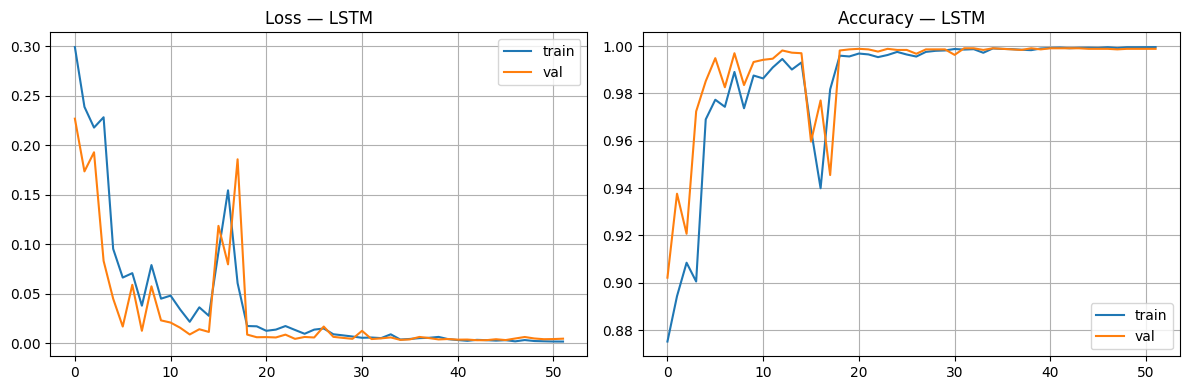

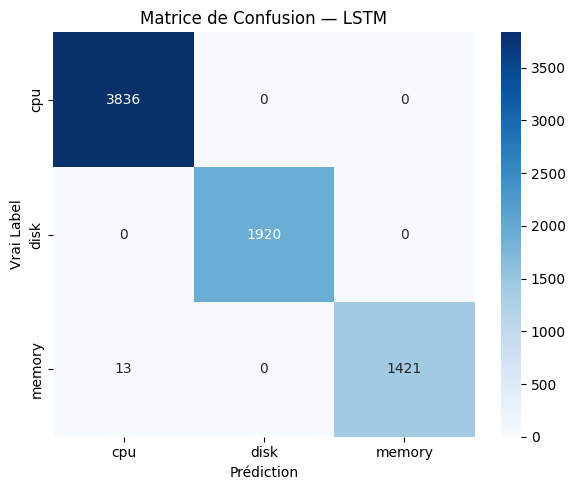

[DEBUG] Modèle et graphiques sauvegardés avec le préfixe : LSTM


In [ ]:
print("[DEBUG] Évaluation des performances ")

nom_modele = "LSTM" # Variable pour nommer les fichiers de sauvegarde

# 1. Prédictions
y_pred = np.argmax(model_lstm.predict(X_test), axis=1)
y_pred_proba = model_lstm.predict(X_test)

# 2. Calcul des métriques (F1 et MSE)
f1 = f1_score(y_test, y_pred, average='macro')
mse = np.mean((tf.keras.utils.to_categorical(y_test, len(le.classes_)) - y_pred_proba) ** 2)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"[DEBUG] {nom_modele} — F1={f1:.4f}  MSE={mse:.4f}")

# 3. Affichage et SAUVEGARDE des courbes Loss et Accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (key, title) in enumerate([('loss', 'Loss'), ('accuracy', 'Accuracy')]):
    ax[i].plot(history.history[key], label='train')
    ax[i].plot(history.history[f'val_{key}'], label='val')
    ax[i].set_title(f'{title} — {nom_modele}')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
# Sauvegarde de la figure des courbes
plt.savefig(f'courbes_{nom_modele}.png', dpi=150)
plt.show()

# 4. Affichage et SAUVEGARDE de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matrice de Confusion — {nom_modele}')
plt.ylabel('Vrai Label')
plt.xlabel('Prédiction')

plt.tight_layout()
# Sauvegarde de la figure de la matrice
plt.savefig(f'confusion_{nom_modele}.png', dpi=150)
plt.show()

# 5. Sauvegarde finale du modèle
model_lstm.save(f'{nom_modele}_model.keras')
print(f"[DEBUG] Modèle et graphiques sauvegardés avec le préfixe : {nom_modele}")

# Partie 2 : CNN 1D

## 3 Modèles :

- Modele A — Simple   : 2 Conv, facile a comprendre
- Modele B — Profond  : 3 blocs de 2 Conv, patterns plus complexes
- Modele C — Residuel : skip connections contre le vanishing gradient

### Modele A : Simple

2 convolution, 64 filtres sur 3 pas

In [ ]:
def build_cnn_simple(seq_len, n_feat, n_classes):
    return Sequential([
        Conv1D(64, 3, padding='same', kernel_regularizer=l2(1e-3),
               input_shape=(seq_len, n_feat)),
        BatchNormalization(), Activation('relu'), Dropout(0.2),
        MaxPooling1D(2),
        Conv1D(128, 3, padding='same', kernel_regularizer=l2(1e-3)),
        BatchNormalization(), Activation('relu'), Dropout(0.3),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'), Dropout(0.3),
        Dense(n_classes, activation='softmax')
    ])

### Modele B : Profond

- 3 filtres a chaque fois plus grand que le precedent (32 -> 64 -> 128) mais pas trop sinon sur apprentissage / pattern trop abstrait
- drop out croissant (i*.1)

In [ ]:
def build_cnn_profond(seq_len, n_feat, n_classes):
    model = Sequential()
    for i, filters in enumerate([32, 64, 128]):
        kw = {'input_shape': (seq_len, n_feat)} if i == 0 else {}
        model.add(Conv1D(filters, 3, padding='same', kernel_regularizer=l2(1e-3), **kw))
        model.add(BatchNormalization()); model.add(Activation('relu'))
        model.add(Conv1D(filters, 3, padding='same', kernel_regularizer=l2(1e-3)))
        model.add(BatchNormalization()); model.add(Activation('relu'))
        if i < 2:
            model.add(MaxPooling1D(2))
        model.add(Dropout(.2 + i * .1))
    model.add(GlobalAveragePooling1D())
    model.add(Dense(64, activation='relu')); model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation='softmax'))
    return model


### Modele C : Residuel



In [ ]:
def bloc_residuel(x, filters):
    shortcut = x
    x = Conv1D(filters, 3, padding='same', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = Conv1D(filters, 3, padding='same', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x)
    # si dimensions differentes, on projette le raccourci avec Conv1D(1)
    if shortcut.shape[-1] != filters:
        shortcut = BatchNormalization()(Conv1D(filters, 1, padding='same')(shortcut))
    return Activation('relu')(Add()([x, shortcut]))


def build_cnn_residuel(seq_len, n_feat, n_classes):
    inp = Input(shape=(seq_len, n_feat))
    x   = Activation('relu')(BatchNormalization()(
              Conv1D(32, 7, padding='same', kernel_regularizer=l2(1e-3))(inp)))
    for filters in [32, 64, 128]:
        x = bloc_residuel(x, filters)
        if filters < 128:
            x = MaxPooling1D(2)(x)
        x = Dropout(0.3)(x)
    x   = GlobalAveragePooling1D()(x)
    x   = Dropout(0.4)(Dense(64, activation='relu')(x))
    out = Dense(n_classes, activation='softmax')(x)
    return Model(inp, out)

## Entrainement & Evaluation :

In [ ]:
def train_and_evaluate(model, X, y, le, nom, save_dir="."):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    history = model.fit(
        X_train, y_train, epochs=100, batch_size=32,
        validation_split=0.15, verbose=1,
        callbacks=CALLBACKS
    )

    y_pred       = np.argmax(model.predict(X_test), axis=1)
    y_pred_proba = model.predict(X_test)
    f1  = f1_score(y_test, y_pred, average='macro')
    mse = np.mean((tf.keras.utils.to_categorical(
                       y_test, len(le.classes_)) - y_pred_proba) ** 2)

    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print(f"[DEBUG] {nom} — F1={f1:.4f}  MSE={mse:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for i, (key, title) in enumerate([('loss', 'Loss'), ('accuracy', 'Accuracy')]):
        ax[i].plot(history.history[key], label='train')
        ax[i].plot(history.history[f'val_{key}'], label='val')
        ax[i].set_title(f'{title} — {nom}')
        ax[i].legend()
        ax[i].grid(True)

    plt.tight_layout()
    chemin_courbes = os.path.join(save_dir, f'courbes_{nom}.png')
    plt.savefig(chemin_courbes, dpi=150)
    plt.show()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion — {nom}')
    plt.tight_layout()

    chemin_cm = os.path.join(save_dir, f'confusion_{nom}.png')
    plt.savefig(chemin_cm, dpi=150)
    plt.show()

    chemin_modele = os.path.join(save_dir, f'{nom}.keras')
    model.save(chemin_modele)

    return f1, mse

## Pipeline :

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,139 (137.26 KB)

 Trainable params: 34,755 (135.76 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9024 - loss: 0.3029 - val_accuracy: 0.8999 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9372 - loss: 0.2051 - val_accuracy: 0.8836 - val_loss: 0.3163 - learning_rate: 0.0010
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9461 - loss: 0.1772 - val_accuracy: 0.8700 - val_loss: 0.3176 - learning_rate: 0.0010
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9504 - loss: 0.1648 - val_accuracy: 0.9142 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9541 - loss: 0.1569 - val_accuracy: 0.8785 - val_loss: 0.2905 - learning_rate: 0.0010
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9637 - loss: 0.1304 - val_accuracy: 0.8672 - val_loss: 0.3290 - learning_rate: 5.0000e-04
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9650 - los

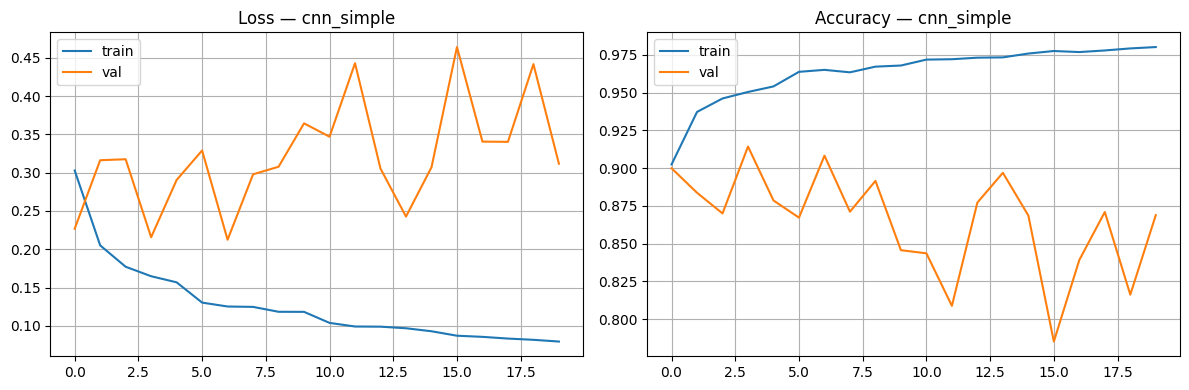

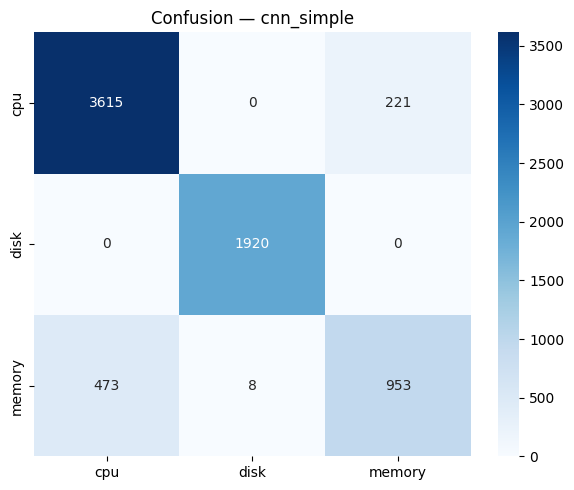

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 25, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 12, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 12, 128)        │             

 Total params: 106,499 (416.01 KB)

 Trainable params: 105,603 (412.51 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9044 - loss: 0.4947 - val_accuracy: 0.9233 - val_loss: 0.3352 - learning_rate: 0.0010
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9397 - loss: 0.2956 - val_accuracy: 0.9553 - val_loss: 0.2246 - learning_rate: 0.0010
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9476 - loss: 0.2430 - val_accuracy: 0.9842 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9554 - loss: 0.2116 - val_accuracy: 0.8982 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9585 - loss: 0.2018 - val_accuracy: 0.9905 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9710 - loss: 0.1546 - val_accuracy: 0.9764 - val_loss: 0.1383 - learning_rate: 5.0000e-04
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9744 - lo

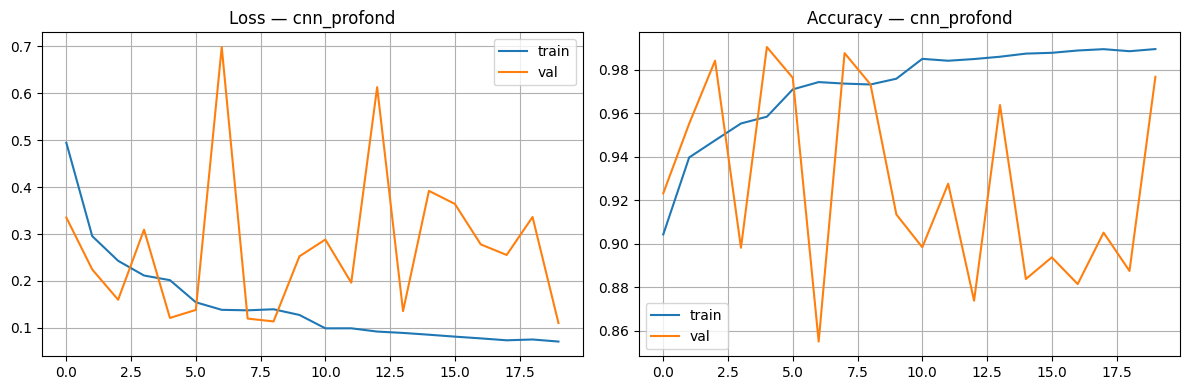

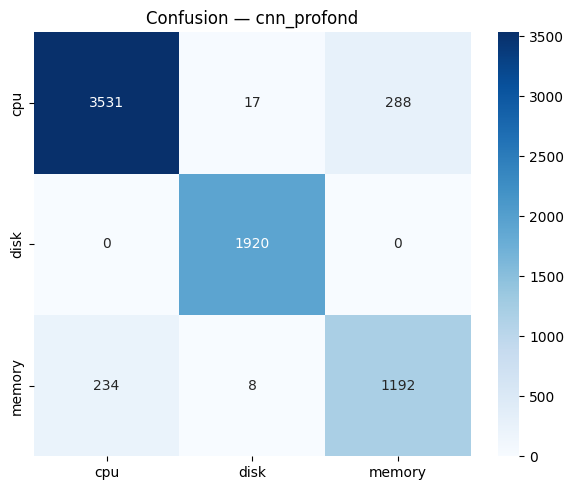

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 50, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 50, 32)    │      1,376 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 32)    │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 50, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 50, 32)    │      3,104 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 32)    │        128 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 50, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 50, 32)    │      3,104 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 32)    │        128 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 50, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 25, 32)    │          0 │ activation_10[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 25, 32)    │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 25, 64)    │      6,208 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 64)    │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 25, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 25, 64)    │     12,352 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 25, 64)    │      2,112 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 64)    │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 121,699 (475.39 KB)

 Trainable params: 120,355 (470.14 KB)

 Non-trainable params: 1,344 (5.25 KB)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.8981 - loss: 0.5133 - val_accuracy: 0.9694 - val_loss: 0.2667 - learning_rate: 0.0010
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9403 - loss: 0.2866 - val_accuracy: 0.9847 - val_loss: 0.1607 - learning_rate: 0.0010
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9552 - loss: 0.2156 - val_accuracy: 0.9189 - val_loss: 0.2552 - learning_rate: 0.0010
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9585 - loss: 0.1940 - val_accuracy: 0.9205 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9654 - loss: 0.1707 - val_accuracy: 0.9080 - val_loss: 0.2406 - learning_rate: 0.0010
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9765 - loss: 0.1322 - val_accuracy: 0.8563 - val_loss: 0.4388 - learning_rate: 5.0000e-04
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9757 - lo

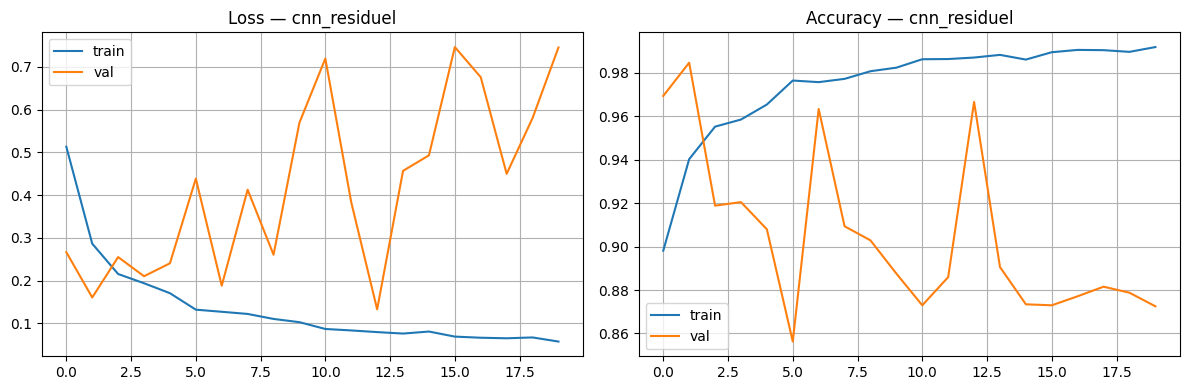

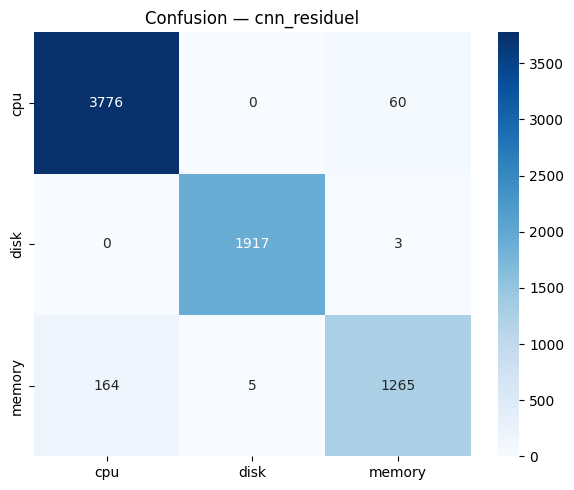


[DEBUG] comparaison finale :
  cnn_simple            F1=0.8804  MSE=0.0391
  cnn_profond           F1=0.9136  MSE=0.0339
  cnn_residuel          F1=0.9617  MSE=0.0188


In [ ]:
SAVE_DIR = "resultats/CNN"

if os.path.exists(SAVE_DIR):
    for root, dirs, files in os.walk(SAVE_DIR, topdown=False):
        for f in files:
            os.remove(os.path.join(root, f))
        for d in dirs:
            os.rmdir(os.path.join(root, d))
    os.rmdir(SAVE_DIR)
os.makedirs(SAVE_DIR)

modeles = {
    'cnn_simple'  : build_cnn_simple(T, F, C),
    'cnn_profond' : build_cnn_profond(T, F, C),
    'cnn_residuel': build_cnn_residuel(T, F, C),
}

resultats = {}
for nom, model in modeles.items():
    model.summary()
    f1, mse = train_and_evaluate(model, X, y, le, nom, save_dir=SAVE_DIR)
    resultats[nom] = {'f1': f1, 'mse': mse}

print("\n[DEBUG] comparaison finale :")
for nom, s in resultats.items():
    print(f"  {nom:20s}  F1={s['f1']:.4f}  MSE={s['mse']:.4f}")

# Partie 3 : Transformer

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

def get_positional_encoding(seq_len, d_model):
    arg = np.arange(seq_len)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model))
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(arg[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(arg[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

def transformer_encoder_layer(inputs, head_size, num_heads, ff_dim, rate=0.1):
    # Multi-Head Attention
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    attention = layers.Dropout(rate)(attention)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed Forward
    outputs = layers.Dense(ff_dim, activation="relu")(x)
    outputs = layers.Dense(inputs.shape[-1])(outputs)
    outputs = layers.Dropout(rate)(outputs)
    return layers.LayerNormalization(epsilon=1e-6)(x + outputs)

def build_transformer_encoder(T, F, C):
    d_model = 64 # Dimension interne
    inputs = layers.Input(shape=(T, F))

    # Projection et Positional Encoding
    x = layers.Dense(d_model)(inputs)
    x += get_positional_encoding(T, d_model)

    # Empilement de 2 couches d'Encoder
    x = transformer_encoder_layer(x, head_size=d_model, num_heads=4, ff_dim=128)
    x = transformer_encoder_layer(x, head_size=d_model, num_heads=4, ff_dim=128)

    # Réduction pour classification
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(C, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="transformer_encoder")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Model: "transformer_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 50, 64)    │        448 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 64)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     66,368 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 50, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 64)    │          0 │ add_3[0][0],      │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 50, 64)    │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 50, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 50, 64)    │          0 │ dense_12[0][0]  

 Total params: 167,043 (652.51 KB)

 Trainable params: 167,043 (652.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8808 - loss: 0.2847 - val_accuracy: 0.9601 - val_loss: 0.1175 - learning_rate: 0.0010
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9588 - loss: 0.1089 - val_accuracy: 0.9884 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9837 - loss: 0.0567 - val_accuracy: 0.9787 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9845 - loss: 0.0544 - val_accuracy: 0.9576 - val_loss: 0.1021 - learning_rate: 0.0010
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9856 - loss: 0.0494 - val_accuracy: 0.9859 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9944 - loss: 0.0228 - val_accuracy: 0.9968 - val_loss: 0.0144 - learning_rate: 5.0000e-04
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9897 - lo

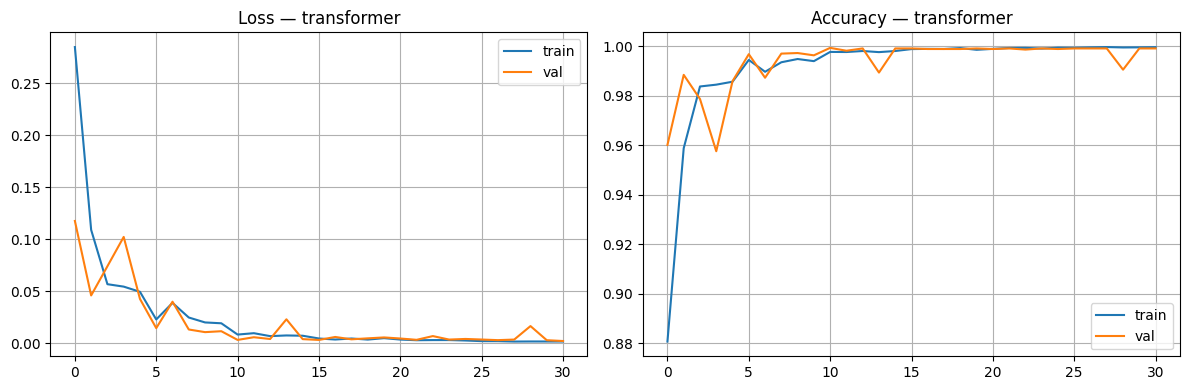

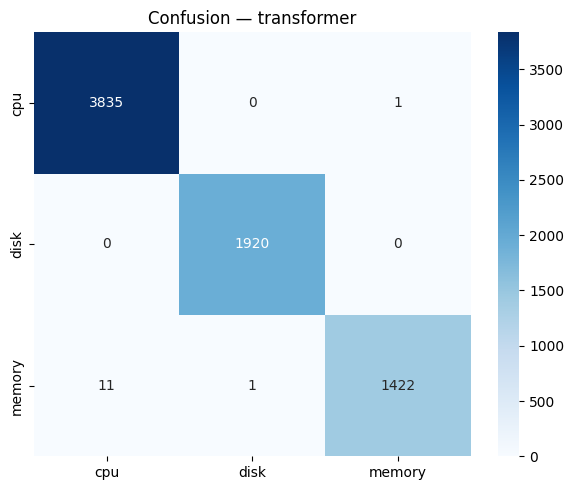

In [ ]:
nom_modele = 'transformer'
model_tf = build_transformer_encoder(T, F, C)
model_tf.summary()

# Entraînement et sauvegarde (Modèle .keras + Courbes/Matrices .png via ta fonction)
f1_tf, mse_tf = train_and_evaluate(model_tf, X, y, le, nom_modele, save_dir=SAVE_DIR)